In [28]:
r=np.array([15.97,15.95])/2*1e-3
Delta_r=0.02/2*1e-3
m=np.array([26.006,26.116])*1e-3
Delta_m=0.002*1e-3
V=np.array([5460.0,5370.0])*1e-6
Delta_V=5*1e-6
p_0=1007.2*100
Delta_p_0=0.5*100
T=np.array([round_to_sigs(50.21/50,0.3/50,r"\s")[0],round_to_sigs(46.04/50,0.3/50,r"\s")[0]])
Delta_T=round_to_sigs(50.21/50,0.3/50,r"\s")[1]
p=g*m/(np.pi*r**2) + p_0
Delta_p=sqrt((np.pi**2*Delta_p_0**2*r**6 + 4*Delta_r**2*g**2*m**2 + r**2*(Delta_g**2*m**2 + Delta_m**2*g**2))/r**6)/np.pi
p,Delta_p,_,latexp = v_round(p, Delta_p,r"\hecto\pascal")
kappa=4*V*m/(T**2*p*r**4)
Delta_kappa=kappa*np.sqrt(4*Delta_T**2/T**2 + Delta_V**2/V**2 + Delta_m**2/m**2 + Delta_p**2/p**2 + 16*Delta_r**2/r**2)
kappa,Delta_kappa,latexk,_=v_round(kappa,Delta_kappa,r"")
for i in range(len(kappa)):
    print(latexk[i])

\num{1.357(0.018)}
\num{1.603(0.023)}


AUFGABE 1: REIBUNG

w_F= 68.1 b=68.01114487546754
0.0014575792470416166
0.00145 4e-05
479.0 14.0


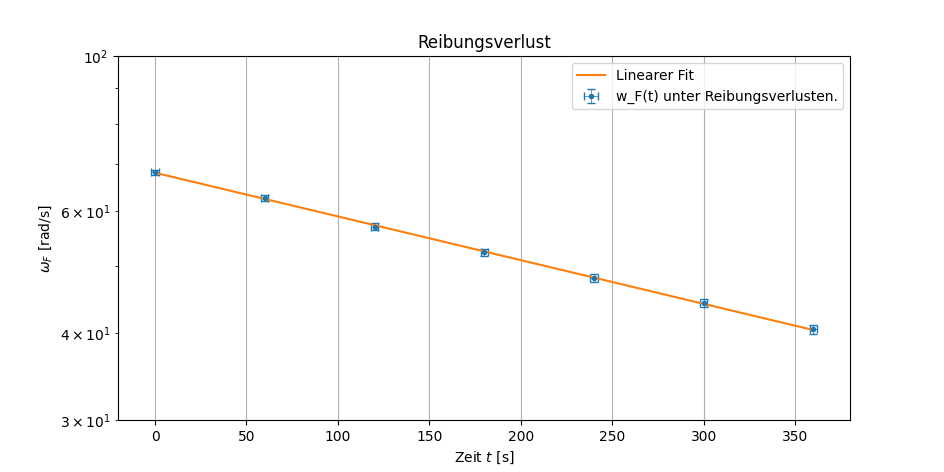

In [ ]:
zeiten=np.array([0,60,120,180,240,300,360])
delta_zeiten=2
w_F=np.array([650,596,543,499,458,422,386])*2*c.pi/60
delta_w_F=5*2*c.pi/60

w_F,delta_w_F,_ = v_round(w_F.astype(float), delta_w_F,einheiten=r"\per\s")

plt.close('all')
fig, ax = plt.subplots(figsize=figsize_cm(12,6))
ax.set_title('Reibungsverlust')
ax.set_ylabel(r'$\omega_F$ [rad/s]')
ax.set_xlabel(r'Zeit $t$ [s]')
ax.set_yscale('log')
ax.set_ylim((3e1,1*1e2))
# ax.set_xlim(())
ax.errorbar(x=zeiten,y=w_F,xerr=delta_zeiten,yerr=delta_w_F,fmt=".",capsize=3,elinewidth=0.5,label='w_F(t) unter Reibungsverlusten.')

def lin(x,a,b):
    return a*x + b
def exp(x,a,b):
    return b*np.exp(a*x)

popt1, pcov1 = curve_fit(lin, zeiten, np.log(w_F), sigma = delta_w_F/w_F,absolute_sigma=True) # Fehler wird durch Logarithmus verändert, aus gff folgt log_fehler=fehler/messwerte
ax.plot(zeiten, exp(zeiten, popt1[0],np.exp(popt1[1])),r'-', label='Linearer Fit')
damp, Delta_damp =round_to_sigs(-popt1[0], np.sqrt(pcov1[0][0]),einheiten=r"\per\s")[0],round_to_sigs(-popt1[0], np.sqrt(pcov1[0][0]),einheiten=r"\per\s")[1]
print(f"w_F= {w_F[0]}",f"b={np.exp(popt1[1])}") # Test, ob b=w_F(t=0) aus w_F=b*exp(-delta t), muss sein, Test geglückt
print(-np.log(500/650)/180) # delta aus einem einzigen Messwert berechnet
print(damp,Delta_damp)
T12, Delta_T12 = (np.log(2)/damp,np.log(2)/damp**2 * Delta_damp)
print(round_to_sigs(T12,Delta_T12,r"\s")[0],round_to_sigs(T12,Delta_T12,r"\s")[1])

ax.grid()
ax.legend()
plt.show()
plt.savefig(Ausgabe_path/"Nr.1_Reibung.png",format="png")



AUFGABE 3.1: UMRECHNUNG DER DATEN

In [ ]:
T_P=np.array([75.8,107.2,49.9,142.9,99.7,56.6,50.2,36.6,23.3,64.4,49.2,27.9])
Delta_T_P=0.5
w_P=2*c.pi/T_P
Delta_w_P=2*c.pi*Delta_T_P/T_P**2
w_P,Delta_w_P,_ = v_round(w_P.astype(float), Delta_w_P,einheiten=r"\per\s")

w_F_i=np.array([493,694,313,682,490,269,670,490,315,630,495,280])*2*c.pi/60
Delta_w_F_i=5*2*c.pi/60
w_F_i,Delta_w_F_i,_=v_round(w_F_i.astype(float),Delta_w_F_i,einheiten=r"\per\s")
gff("w_F_i*e**(-damp*T_P)","w_F_i,damp,T_P")

print(f"{w_P=}")
print(f"{Delta_w_P=}")
print(f"{w_F_i=}")
print(f"{Delta_w_F_i=}")
w_F_f=w_F_i/np.exp(T_P*damp)
Delta_w_F_f= sqrt((Delta_T_P**2*damp**2*w_F_i**2 + Delta_damp**2*T_P**2*w_F_i**2 + Delta_w_F_i**2)/np.exp(2*T_P*damp))
w_F_f,Delta_w_F_f,_ = v_round(w_F_f.astype(float), Delta_w_F_f,einheiten=r"\per\s")
print(f"{w_F_f=}")
print(f"{Delta_w_F_f=}")
bar_w=(w_F_i+w_F_f)/2
Delta_bar_w=1/2*np.sqrt(Delta_w_F_i**2+Delta_w_F_f**2)
bar_w,Delta_bar_w,_ = v_round(bar_w.astype(float), Delta_bar_w,einheiten=r"\per\s")
print(f"{bar_w=}")
print(f"{Delta_bar_w=}")

Funktion:


<IPython.core.display.Math object>

e^{- T_{P} damp} w_{F i}
Absoluter Fehler:


<IPython.core.display.Math object>

\sqrt{e^{- 2 T_{P} damp} \left(\Delta_{T P}^{2} damp^{2} w_{F i}^{2} \log{\left(e \right)}^{2} + \Delta_{damp}^{2} T_{P}^{2} w_{F i}^{2} \log{\left(e \right)}^{2} + \Delta_{w F i}^{2}\right)}
Relativer Fehler:


<IPython.core.display.Math object>

\sqrt{\Delta_{T P}^{2} damp^{2} \log{\left(e \right)}^{2} + \Delta_{damp}^{2} T_{P}^{2} \log{\left(e \right)}^{2} + \frac{\Delta_{w F i}^{2}}{w_{F i}^{2}}}
w_P=array([0.0829 , 0.0587 , 0.126  , 0.04397, 0.0631 , 0.1111 , 0.1252 ,
       0.1717 , 0.27   , 0.0976 , 0.1278 , 0.226  ])
Delta_w_P=array([0.0006 , 0.0003 , 0.0013 , 0.00016, 0.0004 , 0.001  , 0.0013 ,
       0.0024 , 0.006  , 0.0008 , 0.0013 , 0.005  ])
w_F_i=array([51.7, 72.7, 32.8, 71.5, 51.4, 28.2, 70.2, 51.4, 33. , 66. , 51.9,
       29.4])
Delta_w_F_i=array([0.6, 0.6, 0.6, 0.6, 0.6, 0.6, 0.6, 0.6, 0.6, 0.6, 0.6, 0.6])
w_F_f=array([46.4, 62.3, 30.6, 58.2, 44.5, 26. , 65.3, 48.8, 32. , 60.2, 48.4,
       28.3])
Delta_w_F_f=array([0.6, 0.6, 0.6, 0.6, 0.6, 0.6, 0.6, 0.6, 0.6, 0.6, 0.6, 0.6])
bar_w=array([49.1, 67.5, 31.7, 64.9, 48. , 27.1, 67.8, 50.1, 32.5, 63.1, 50.2,
       28.9])
Delta_bar_w=array([0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5])


a_$m-20$ cm=\qty{1.602(0.020)}{\s\squared}
a_$m-15$ cm=\qty{2.275(0.019)}{\s\squared}
a_$2m-20$ cm=\qty{0.763(0.021)}{\s\squared}
a_$2m-15$ cm=\qty{1.061(0.021)}{\s\squared}


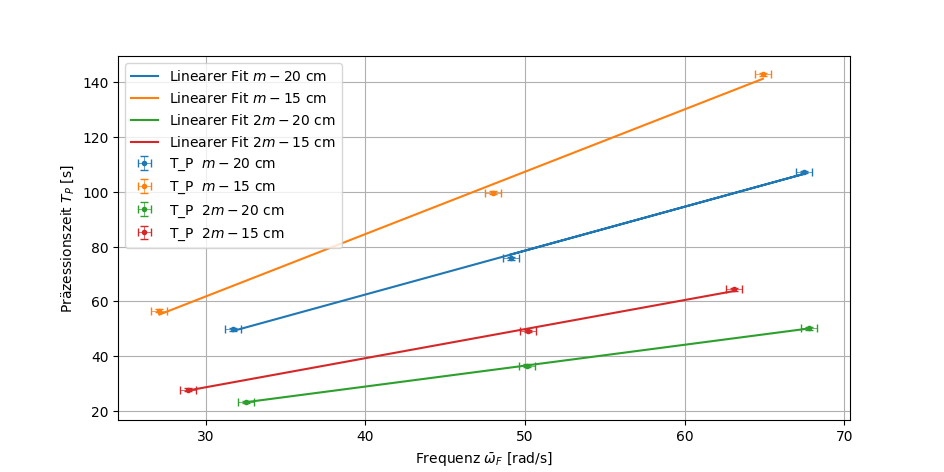

In [ ]:
plt.close('all')
fig, ax = plt.subplots(figsize=figsize_cm(12,6))
ax.set_title('  ')
ax.set_ylabel(r'Präzessionszeit $T_P$ [s]')
ax.set_xlabel(r'Frequenz $\bar{\omega}_F$ [rad/s]')
# ax.set_ylim((3e1,1*1e2))
# ax.set_xlim(())
massen=[r'$m-20$ cm',r'$m-15$ cm',r'$2m-20$ cm',r'$2m-15$ cm']
n=3
j=0
a=[]
Delta_a=[]
for i in range(0, len(T_P), n):    
    ax.errorbar(x=bar_w[i : i + n],y=T_P[i : i + n],xerr=Delta_bar_w[i : i + n],yerr=Delta_T_P,fmt=".",capsize=3,elinewidth=0.5,label=f"T_P  {massen[j]}")
    popt, pcov = curve_fit(lin, bar_w[i : i + n], T_P[i : i + n], sigma = Delta_T_P,absolute_sigma=True) 
    ax.plot(bar_w[i : i + n],lin(bar_w[i : i + n], popt[0],popt[1]),r'-', color=f"C{j}",label=f"Linearer Fit {massen[j]}")
    print(f"a_{massen[j]}={round_to_sigs(popt[0],np.sqrt(pcov[0][0]),einheiten=r"\s\squared")[2]}")
    a.append(round_to_sigs(popt[0],np.sqrt(pcov[0][0]),einheiten=r"")[0])
    Delta_a.append(round_to_sigs(popt[0],np.sqrt(pcov[0][0]),einheiten=r"")[1])
    j+=1

ax.grid()
ax.legend()
plt.show()
plt.savefig(Ausgabe_path/"Nr.Präzession.png",format="png")



AUFGABE 3.2: $I_Z$ BERECHNUNG

In [ ]:
a=np.array(a)
Delta_a=np.array(Delta_a)

l=np.array([0.2,0.15,0.2,0.15])
Delta_l=0.003
m=np.array([9.85,9.85,2*9.85,2*9.85])*1e-3
I_z=a*g*l*m/(2*c.pi)
Delta_I_z=I_z*np.sqrt(Delta_a**2/a**2 + Delta_g**2/g**2 + Delta_l**2/l**2)
I_z,Delta_I_z,latex_I_z= v_round(I_z.astype(float), Delta_I_z,r"\kg\m\squared")
for i, line in enumerate(latex_I_z):
    print(f"I_{{{massen[i]}}}={line}") # Fügt am Ende das LaTeX-Zeilenende \\ hinzu
bar_I_z=np.sum(I_z)/4
stdIz = np.std(I_z)
Delta_barIz = np.sqrt((np.sum(Delta_I_z)/4)**2+(stdIz/4)**2)
print(round_to_sigs(bar_I_z,Delta_barIz,r"\kg\m\squared")[2])


I_{$m-20$ cm}=\qty{0.00493(0.00010)}{\kg\m\squared}
I_{$m-15$ cm}=\qty{0.00525(0.00012)}{\kg\m\squared}
I_{$2m-20$ cm}=\qty{0.00470(0.00015)}{\kg\m\squared}
I_{$2m-15$ cm}=\qty{0.00490(0.00014)}{\kg\m\squared}
\qty{0.00495(0.00014)}{\kg\m\squared}


In [ ]:
gff("a*m*g*l/(2*pi)","a,g,l")

Funktion:


<IPython.core.display.Math object>

\frac{a g l m}{2 \pi}
Absoluter Fehler:


<IPython.core.display.Math object>

\frac{\sqrt{m^{2} \left(\Delta_{a}^{2} g^{2} l^{2} + \Delta_{g}^{2} a^{2} l^{2} + \Delta_{l}^{2} a^{2} g^{2}\right)}}{2 \pi}
Relativer Fehler:


<IPython.core.display.Math object>

\sqrt{\frac{\Delta_{a}^{2}}{a^{2}} + \frac{\Delta_{g}^{2}}{g^{2}} + \frac{\Delta_{l}^{2}}{l^{2}}}


(a*g*l*m/(2*pi),
 sqrt(m**2*(Delta_a**2*g**2*l**2 + Delta_g**2*a**2*l**2 + Delta_l**2*a**2*g**2))/(2*pi),
 sqrt(Delta_a**2/a**2 + Delta_g**2/g**2 + Delta_l**2/l**2),
 [(a, Delta_a), (g, Delta_g), (l, Delta_l)])

AUFGABE 5.1: BERECHUNG m1 für $I_x$

\qty{173(5)}{}


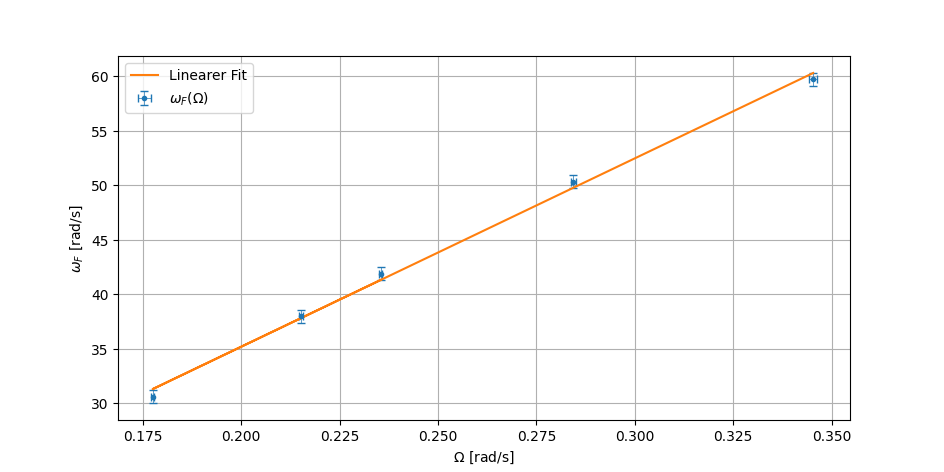

0.0028960324355632784
0.0196078431372549


In [ ]:
T_w=np.array([18.2,22.1,29.2,35.4,26.7])
w=2*pi/T_w
Delta_T_w=0.5/10
Delta_w=2*c.pi*Delta_T_w/T_w**2
w,Delta_w,_ = v_round(w.astype(float), Delta_w,r"\per\s")
w_F=np.array([570,480,362,292,400])*2*c.pi/60
Delta_w_F=5*2*c.pi/60
w_F,Delta_w_F,_=v_round(w_F.astype(float),Delta_w_F,r"\per\s")

plt.close('all')
fig, ax = plt.subplots(figsize=figsize_cm(12,6))
ax.set_xlabel(r'$\Omega$ [rad/s]')
ax.set_ylabel(r'$\omega_F$ [rad/s]')
# ax.set_ylim((3e1,1*1e2))
# ax.set_xlim(())
ax.errorbar(x=w,y=w_F,xerr=Delta_w,yerr=Delta_w_F,fmt=".",capsize=3,elinewidth=0.5,label=r'$\omega_F(\Omega)$')

popt, pcov = curve_fit(lin, w,w_F, sigma =Delta_w_F,absolute_sigma=True) 
ax.plot(w, lin(w, popt[0], popt[1]),r'-', label='Linearer Fit')
m=round_to_sigs(popt[0],np.sqrt(pcov[0][0]),r"")[0]
Delta_m=round_to_sigs(popt[0],np.sqrt(pcov[0][0]),r"")[1]

print(round_to_sigs(popt[0],np.sqrt(pcov[0][0]),r"")[2])
ax.grid()
ax.legend()
plt.show()
plt.savefig(Ausgabe_path/"Nr.4_w-w_F.png",format="png")

print(max(Delta_w/w))
print(max(Delta_w_F/w_F))


AUFGABE 5.1: BERECHNUNG $I_x$

In [ ]:
bar_I_z,Delta_barIz=round_to_sigs(bar_I_z,Delta_barIz,r"\kg\m\squared")[0],round_to_sigs(bar_I_z,Delta_barIz,r"\kg\m\squared")[1]
I_x=-bar_I_z*m/(1 - m)
Delta_I_x =I_x*sqrt(Delta_barIz**2/bar_I_z**2 + Delta_m**2/(m**2*(m - 1)**2))
print(round_to_sigs(I_x,Delta_I_x,r"\kg\m\squared")[2])
print(Delta_m**2/(m**2*(m - 1)))
gff("-m*I_z/(1-m)","m,I_z")

\qty{0.00498(0.00015)}{\kg\m\squared}
4.856454850122033e-06
Funktion:


<IPython.core.display.Math object>

- \frac{I_{z} m}{1 - m}
Absoluter Fehler:


<IPython.core.display.Math object>

\sqrt{\frac{\Delta_{I z}^{2} m^{2} \left(m - 1\right)^{2} + \Delta_{m}^{2} I_{z}^{2}}{\left(m - 1\right)^{4}}}
Relativer Fehler:


<IPython.core.display.Math object>

\sqrt{\frac{\Delta_{I z}^{2}}{I_{z}^{2}} + \frac{\Delta_{m}^{2}}{m^{2} \left(m - 1\right)^{2}}}


(-I_z*m/(1 - m),
 sqrt((Delta_I_z**2*m**2*(m - 1)**2 + Delta_m**2*I_z**2)/(m - 1)**4),
 sqrt(Delta_I_z**2/I_z**2 + Delta_m**2/(m**2*(m - 1)**2)),
 [(m, Delta_m), (I_z, Delta_I_z)])

AUFAGBE 5 AGAIN: BERECHNUNG m2 und I_x2

\qty{0.00553(0.00003)}{}
\qty{0.00498(0.00015)}{\kg\m\squared}
(0.007, '\\num{0.007}')


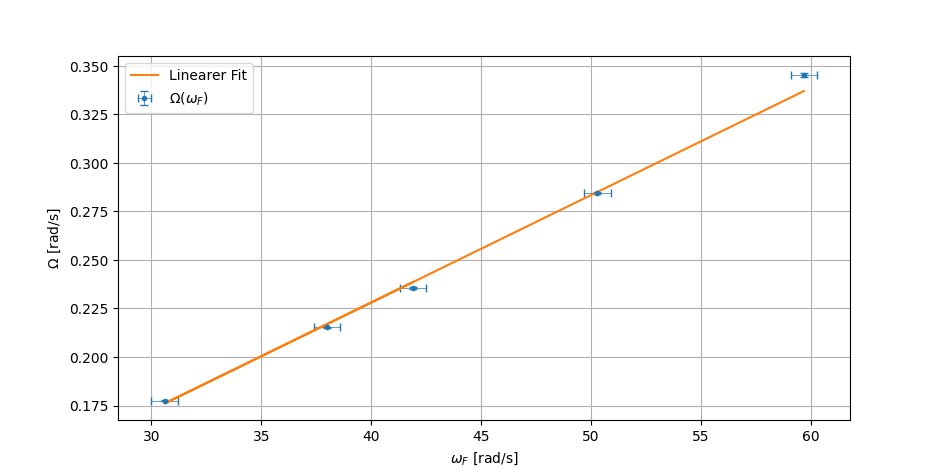

In [ ]:
plt.close('all')
fig, ax = plt.subplots(figsize=figsize_cm(12,6))
ax.set_ylabel(r'$\Omega$ [rad/s]')
ax.set_xlabel(r'$\omega_F$ [rad/s]')
# ax.set_ylim((3e1,1*1e2))
# ax.set_xlim(())
ax.errorbar(x=w_F,y=w,xerr=Delta_w_F,yerr=Delta_w,fmt=".",capsize=3,elinewidth=0.5,label=r'$\Omega(\omega_F)$')

popt, pcov = curve_fit(lin, w_F,w, sigma =Delta_w,absolute_sigma=True) 
ax.plot(w_F, lin(w_F, popt[0], popt[1]),r'-', label='Linearer Fit')
m2=round_to_sigs(popt[0],np.sqrt(pcov[0][0]),r"")[0]
Delta_m2=round_to_sigs(popt[0],np.sqrt(pcov[0][0]),r"")[1]
print(round_to_sigs(popt[0],np.sqrt(pcov[0][0]),r"")[2])
ax.grid()
ax.legend()


barz,Delta_barIz=round_to_sigs(bar_I_z,Delta_barIz,r"\kg\m\squared")[0],round_to_sigs(bar_I_z,Delta_barIz,r"\kg\m\squared")[1]
I_x2=barz/(1-m2)
Delta_I_x2 = sqrt((Delta_barIz**2*(m2 - 1)**2 + Delta_m2**2*barz**2)/(m2 - 1)**4)
print(round_to_sigs(I_x2,Delta_I_x2,r"\kg\m\squared")[2])
print(sigma_abweichung(I_x,I_x2,Delta_I_x,Delta_I_x2))
plt.show()

In [ ]:
gff("I_z/(1-m)","I_z,m")

Funktion:


<IPython.core.display.Math object>

\frac{I_{z}}{1 - m}
Absoluter Fehler:


<IPython.core.display.Math object>

\sqrt{\frac{\Delta_{I z}^{2} \left(m - 1\right)^{2} + \Delta_{m}^{2} I_{z}^{2}}{\left(m - 1\right)^{4}}}
Relativer Fehler:


<IPython.core.display.Math object>

\sqrt{\frac{\Delta_{I z}^{2}}{I_{z}^{2}} + \frac{\Delta_{m}^{2}}{\left(m - 1\right)^{2}}}


(I_z/(1 - m),
 sqrt((Delta_I_z**2*(m - 1)**2 + Delta_m**2*I_z**2)/(m - 1)**4),
 sqrt(Delta_I_z**2/I_z**2 + Delta_m**2/(m - 1)**2),
 [(I_z, Delta_I_z), (m, Delta_m)])

AUFGABE 6: BERECHUNG $I_x$ AUF ZWEITEN WEG

0.951 0.011
0.00495 0.00014
\qty{0.00521(0.00016)}{\kg\m\squared}


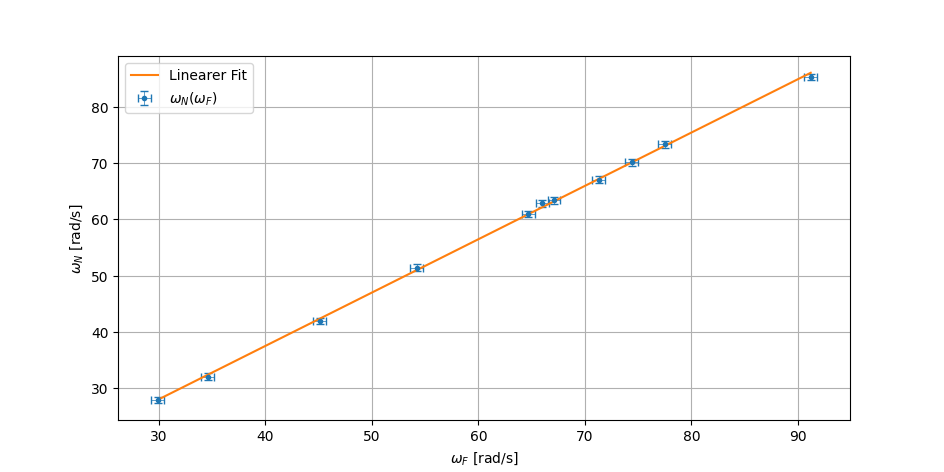

In [ ]:
w_F=np.array([870,740,710,680,640,630,617,517,430,330,285])*2*c.pi/60
Delta_w_F=Delta_w_N=2*c.pi*5/60
w_N=np.array([815,700,670,640,605,600,582,490,400,305,265])*2*c.pi/60
w_F,Delta_w_F,_ = v_round(w_F.astype(float), Delta_w_F,r"\per\s")
w_N,Delta_w_N,_=v_round(w_N.astype(float),Delta_w_N,r"\per\s")

plt.close('all')
fig, ax = plt.subplots(figsize=figsize_cm(12,6))
ax.set_ylabel(r'$\omega_N$ [rad/s]')
ax.set_xlabel(r'$\omega_F$ [rad/s]')
# ax.set_ylim((3e1,1*1e2))
# ax.set_xlim(())
ax.errorbar(x=w_F,y=w_N,xerr=Delta_w_F,yerr=Delta_w_N,fmt=".",capsize=3,elinewidth=0.5,label=r'$\omega_N(\omega_F)$')

popt, pcov = curve_fit(lin, w_F,w_N, sigma =Delta_w_N,absolute_sigma=True) 
ax.plot(w_F, lin(w_F, popt[0], popt[1]),r'-', label='Linearer Fit')
m=round_to_sigs(popt[0],np.sqrt(pcov[0][0]),r"")[0]
Delta_m=round_to_sigs(popt[0],np.sqrt(pcov[0][0]),r"")[1]
print(m,Delta_m)
print(bar_I_z,Delta_barIz)
ax.grid()
ax.legend()
I_x=bar_I_z/m
Delta_I_x=I_x* sqrt(Delta_barIz**2/bar_I_z**2 + Delta_m**2/m**2)
print(round_to_sigs(I_x,Delta_I_x,r"\kg\m\squared")[2])

plt.show()
plt.savefig(Ausgabe_path/"Nr.5_w_N-w_F.png",format="png")


In [ ]:
gff("I_z/m","I_z,m")

Funktion:


<IPython.core.display.Math object>

\frac{I_{z}}{m}
Absoluter Fehler:


<IPython.core.display.Math object>

\sqrt{\frac{\Delta_{I z}^{2} m^{2} + \Delta_{m}^{2} I_{z}^{2}}{m^{4}}}
Relativer Fehler:


<IPython.core.display.Math object>

\sqrt{\frac{\Delta_{I z}^{2}}{I_{z}^{2}} + \frac{\Delta_{m}^{2}}{m^{2}}}


(I_z/m,
 sqrt((Delta_I_z**2*m**2 + Delta_m**2*I_z**2)/m**4),
 sqrt(Delta_I_z**2/I_z**2 + Delta_m**2/m**2),
 [(I_z, Delta_I_z), (m, Delta_m)])

In [ ]:
sigma_abweichung(4.98,5.21,0.16,0.15)

(1.1, '\\num{1.1}')